# 💳 Credit Card Customer Segmentation
### KMeans Clustering — Credit Card Dataset

---

## 📌 Overview
Segmenting credit card customers based on their financial behavior using **KMeans Clustering**.  
Helps banks identify distinct customer groups for targeted marketing and risk management.

## 📦 Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Load Data

In [3]:
df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 🔍 Explore Data

In [4]:
print(df.shape)
print(df.info())

(8950, 18)
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

## 🧹 Data Cleaning

In [5]:
print(df.isnull().sum())

df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
print("Missing values(MINIMUM_PAYMENTS):", df["MINIMUM_PAYMENTS"].isnull().sum())
print("Missing values(CREDIT_LIMIT):", df["CREDIT_LIMIT"].isnull().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Missing values(MINIMUM_PAYMENTS): 0
Missing values(CREDIT_LIMIT): 0


In [6]:
df.drop("CUST_ID", axis=1, inplace=True)
print(df.shape)

(8950, 17)


## ⚙️ Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

## 🔍 Finding Optimal K — Elbow Method

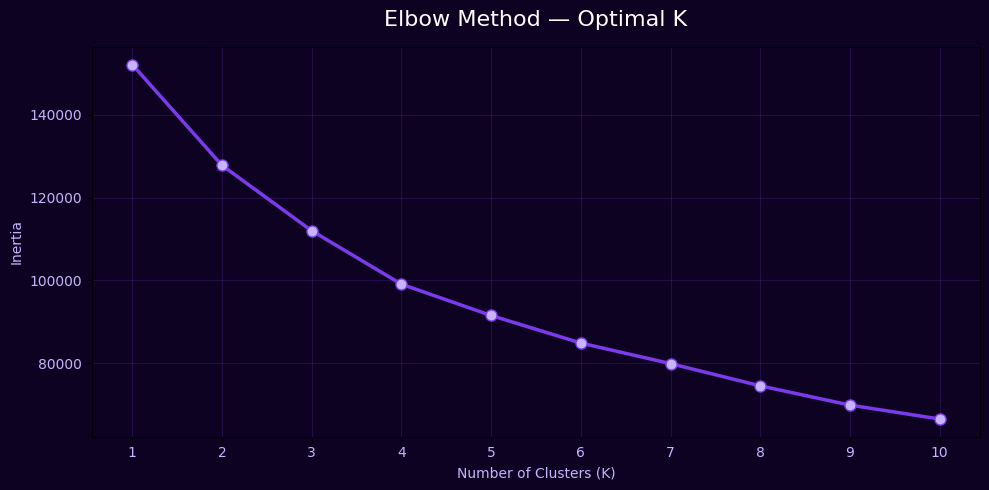

In [8]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), inertia, marker='o', color='#7c3aed', linewidth=2.5, markersize=8, markerfacecolor='#c4b5fd')
plt.title('Elbow Method — Optimal K', fontsize=16, color='white', pad=15)
plt.xlabel('Number of Clusters (K)', color='#c4b5fd')
plt.ylabel('Inertia', color='#c4b5fd')
plt.xticks(range(1, 11), color='#c4b5fd')
plt.yticks(color='#c4b5fd')
plt.grid(True, alpha=0.2, color='#7c3aed')
plt.gca().set_facecolor('#0d0221')
plt.gcf().set_facecolor('#0d0221')
plt.tight_layout()
plt.show()

## 📐 Finding Optimal K — Silhouette Score

K=2 -> Silhouette Score: 0.2100
K=3 -> Silhouette Score: 0.2510
K=4 -> Silhouette Score: 0.1977
K=5 -> Silhouette Score: 0.1931
K=6 -> Silhouette Score: 0.2029
K=7 -> Silhouette Score: 0.2077
K=8 -> Silhouette Score: 0.2217
K=9 -> Silhouette Score: 0.2260
K=10 -> Silhouette Score: 0.2204


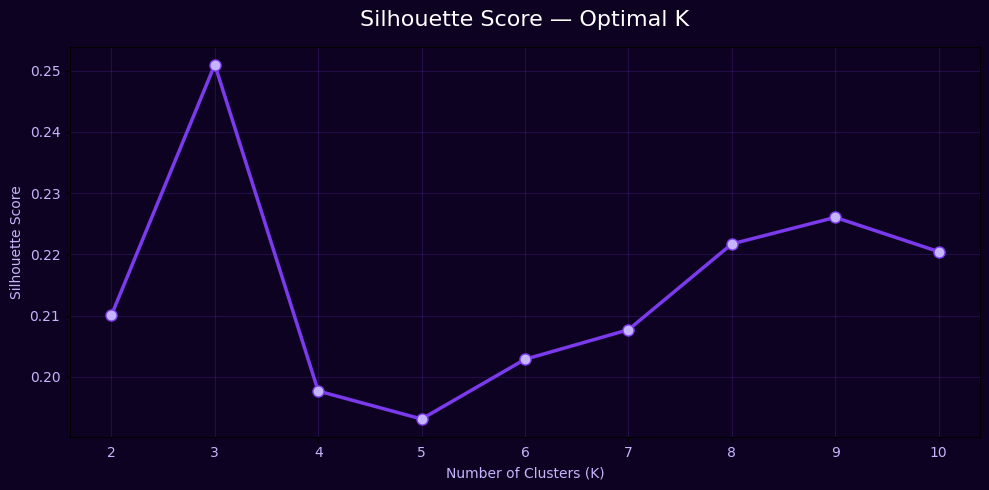

In [9]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    lables = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, lables)
    silhouette_scores.append(score)
    print(f"K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='#7c3aed', linewidth=2.5, markersize=8, markerfacecolor='#c4b5fd')
plt.title('Silhouette Score — Optimal K', fontsize=16, color='white', pad=15)
plt.xlabel('Number of Clusters (K)', color='#c4b5fd')
plt.ylabel('Silhouette Score', color='#c4b5fd')
plt.xticks(range(2, 11), color='#c4b5fd')
plt.yticks(color='#c4b5fd')
plt.grid(True, alpha=0.2, color='#7c3aed')
plt.gca().set_facecolor('#0d0221')
plt.gcf().set_facecolor('#0d0221')
plt.tight_layout()
plt.show()

## 🤖 Training KMeans — K=3

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

print(df["Cluster"].value_counts())

Cluster
1    6114
2    1561
0    1275
Name: count, dtype: int64


## 📊 Cluster Analysis

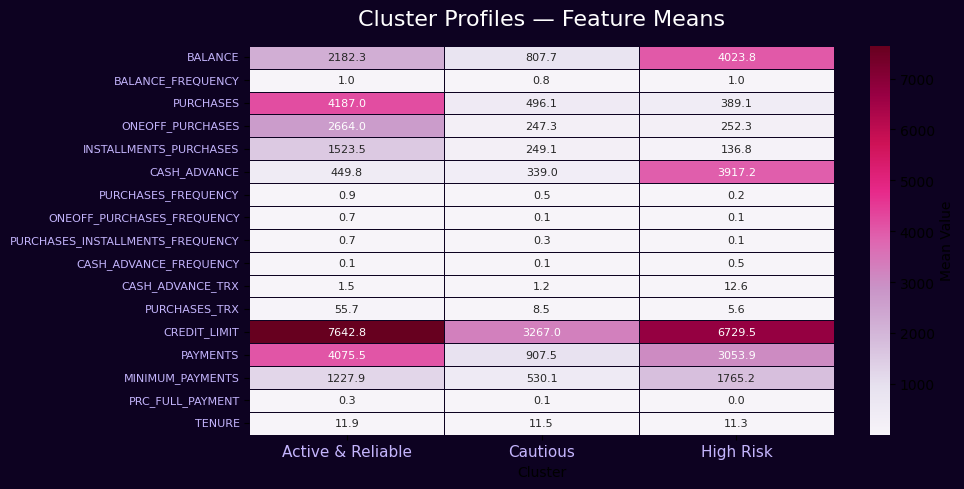

In [12]:
import seaborn as sns
cluster_analysis = df.groupby("Cluster").mean().round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_analysis.T,
    annot=True,
    fmt='.1f',
    cmap='PuRd',
    linewidths=0.5,
    linecolor='#0d0221',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Mean Value'}
)
plt.title('Cluster Profiles — Feature Means', fontsize=16, color='white', pad=15)
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Active & Reliable', 'Cautious', 'High Risk'], color='#c4b5fd', fontsize=11)
plt.yticks(color='#c4b5fd', fontsize=8, rotation=0)
plt.gca().set_facecolor('#0d0221')
plt.gcf().set_facecolor('#0d0221')
plt.tight_layout()
plt.show()


### PCA — Cluster Visualization in 2D

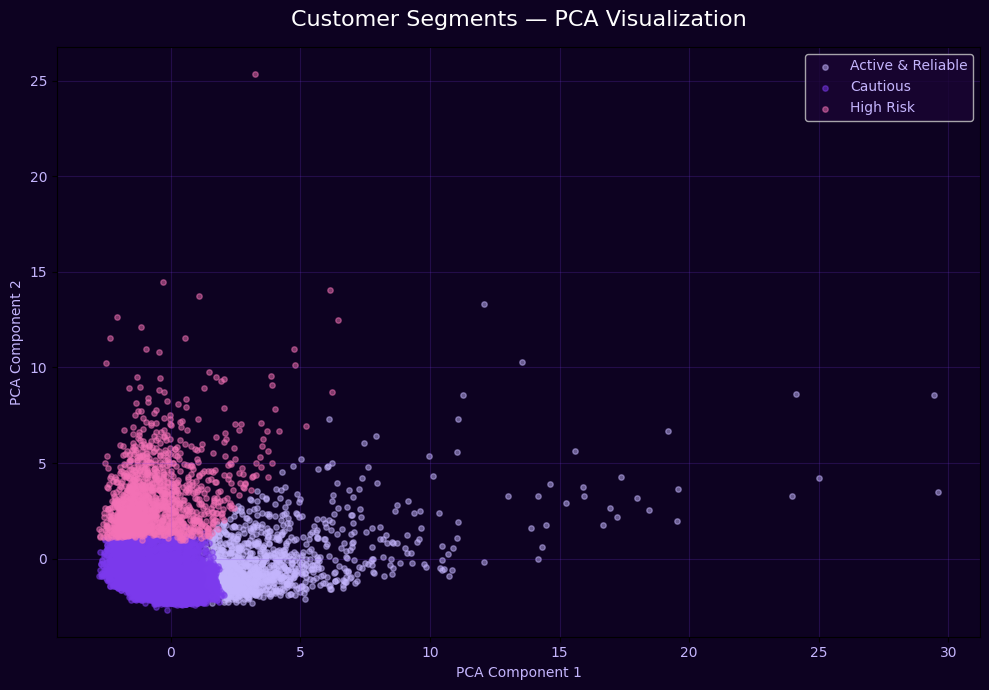

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
colors = ['#c4b5fd', '#7c3aed', '#f472b6']
labels = ['Active & Reliable', 'Cautious', 'High Risk']

for i in range(3):
    mask = df['Cluster'] == i
    plt.scatter(
        df_pca[mask, 0],
        df_pca[mask, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.5,
        s=15
    )

plt.title('Customer Segments — PCA Visualization', fontsize=16, color='white', pad=15)
plt.xlabel('PCA Component 1', color='#c4b5fd')
plt.ylabel('PCA Component 2', color='#c4b5fd')
plt.xticks(color='#c4b5fd')
plt.yticks(color='#c4b5fd')
plt.legend(facecolor='#1a0533', labelcolor='#c4b5fd', fontsize=10)
plt.grid(True, alpha=0.2, color='#7c3aed')
plt.gca().set_facecolor('#0d0221')
plt.gcf().set_facecolor('#0d0221')
plt.tight_layout()
plt.show()

### Bar Chart — Key Features Comparison

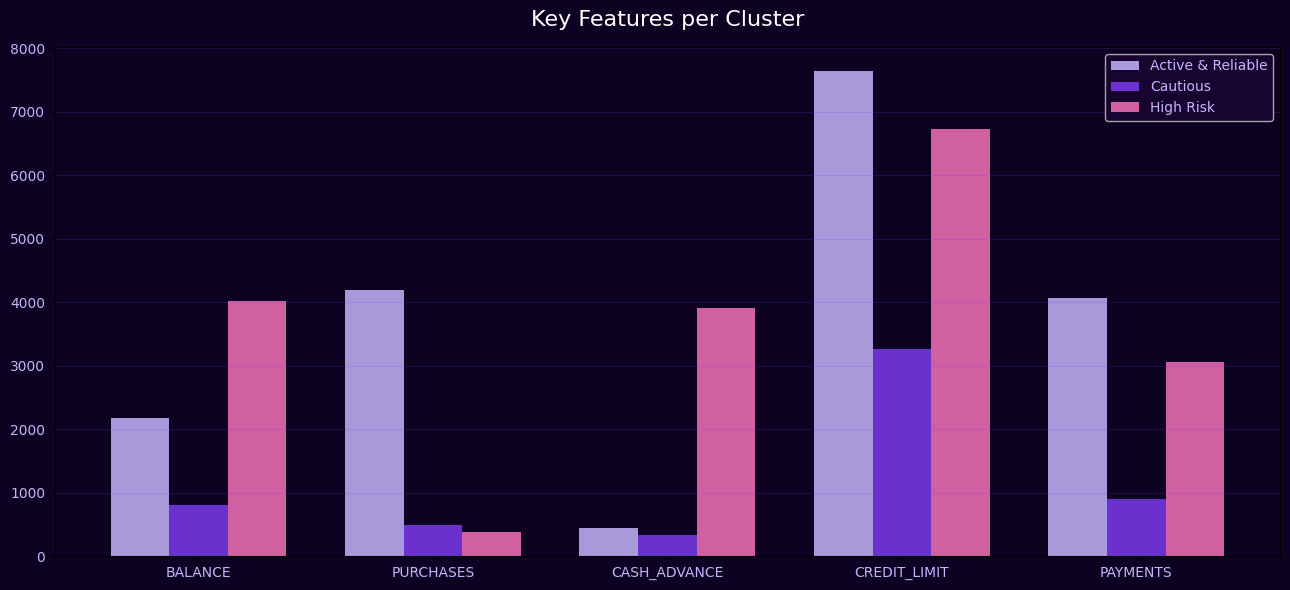

In [14]:
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
cluster_means = df.groupby('Cluster')[features].mean()

x = np.arange(len(features))
width = 0.25
colors = ['#c4b5fd', '#7c3aed', '#f472b6']
labels = ['Active & Reliable', 'Cautious', 'High Risk']

plt.figure(figsize=(13, 6))

for i in range(3):
    plt.bar(x + i * width, cluster_means.iloc[i], width=width, label=labels[i], color=colors[i], alpha=0.85)

plt.title('Key Features per Cluster', fontsize=16, color='white', pad=15)
plt.xticks(x + width, features, color='#c4b5fd', fontsize=10)
plt.yticks(color='#c4b5fd')
plt.legend(facecolor='#1a0533', labelcolor='#c4b5fd', fontsize=10)
plt.grid(True, alpha=0.2, color='#7c3aed', axis='y')
plt.gca().set_facecolor('#0d0221')
plt.gcf().set_facecolor('#0d0221')
plt.tight_layout()
plt.show()

## 📈 Results

| Metric | Value |
|--------|-------|
| 🔢 Optimal K | 3 |
| 📐 Best Silhouette Score | 0.2510 (K=3) |
| 👥 Total Customers | 8,950 |

| Cluster | Profile | Customers |
|---------|---------|-----------|
| 0 | 🟢 Active & Reliable | 1,275 |
| 1 | 🟡 Cautious | 6,114 |
| 2 | 🔴 High Risk | 1,561 |

---

## 💡 Key Insights

- **Elbow Method** alone was inconclusive — Silhouette Score confirmed K=3 as optimal
- **Cluster 1** contains 68% of customers — typical low-activity users
- **Cluster 0** are the most valuable customers — high purchases, high payments, high credit limit
- **Cluster 2** rely heavily on cash advances with minimal purchases — high financial risk
- **Silhouette Score of 0.25** is expected for high-dimensional financial data — not a weakness of the model
- **PCA** confirmed clear separation between clusters visually